Mục tiêu: Quy tác động **retention D7 (≈ −4.3% tương đối)** ra business impact (số user & tiền, ARPU là **tham số** + sensitivity), tổng hợp 3 hypothesis (H0₁ D1, H0₂ D7, H0₃ engagement) và ra recommendation **Go/No-Go**.

Ngày phân tích: 2026-08-08

**Step 1:** Import thư viện và cố định seed

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option('display.float_format', lambda v: f'{v:,.4f}')
np.random.seed(42)
print('Environment ready.')

Environment ready.


**STEP 2:** Load mart (SQL Server, fallback CSV replicate policy)

In [2]:
def load_from_sql():
    import os
    from dotenv import load_dotenv
    import pyodbc
    load_dotenv()
    conn = pyodbc.connect(
        f"DRIVER={{{os.getenv('DB_DRIVER')}}};"
        f"SERVER={os.getenv('DB_SERVER')};DATABASE={os.getenv('DB_NAME')};"
        f"Trusted_Connection={os.getenv('DB_TRUSTED_CONNECTION','yes')};"
    )
    q = ("SELECT userid, version, sum_gamerounds, retention_1, retention_7 "
         "FROM cookie_cats.mart_ab_test_base")
    return pd.read_sql(q, conn)

def load_from_csv():
    raw = pd.read_csv('../data/cookie_cats.csv')
    m = (raw.groupby('userid')
            .agg(version=('version','max'),
                 sum_gamerounds=('sum_gamerounds','max'),
                 retention_1=('retention_1','max'),
                 retention_7=('retention_7','max'))
            .reset_index())
    m = m[m['sum_gamerounds'] != 49854].copy()
    m['retention_1'] = m['retention_1'].astype(int)
    m['retention_7'] = m['retention_7'].astype(int)
    return m

try:
    mart = load_from_sql()
    SOURCE = 'SQL Server (cookie_cats.mart_ab_test_base)'
except Exception:
    mart = load_from_csv()
    SOURCE = 'CSV fallback (mart policy replicated in pandas)'

print(f'Source: {SOURCE} | rows: {len(mart):,}')
assert len(mart) == 90188, 'Row count khac 90,188 -> kiem tra lai mart policy!'
print('Load OK.')

C:\Users\Asus\AppData\Local\Temp\ipykernel_29388\3095890224.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(q, conn)


Source: SQL Server (cookie_cats.mart_ab_test_base) | rows: 90,188
Load OK.


**Step 3:** Khai báo ngưỡng alpha/Bonferroni và hàm verdict

In [3]:
ALPHA, N_TESTS = 0.05, 3
ALPHA_BONF = ALPHA / N_TESTS
def verdict(p):
    if p < ALPHA_BONF: return 'SIGNIFICANT (vuot Bonferroni)'
    if p < ALPHA:      return 'sig o 0.05, KHONG vuot Bonferroni'
    return 'KHONG significant'
print(f'alpha={ALPHA} | Bonferroni={ALPHA_BONF:.4f}')

alpha=0.05 | Bonferroni=0.0167


**STEP 4:** Tái tính retention D1/D7 (χ² + diff + Cohen's h) — nền cho impact & bảng tổng hợp

**NOTE:** notebook self-contained -> tính lại từ mart thay vì phụ thuộc biến từ G1 (kết quả phải trùng G1).

In [4]:
n30 = int((mart['version'] == 'gate_30').sum())
n40 = int((mart['version'] == 'gate_40').sum())

def analyze_retention(df, metric):
    ct  = pd.crosstab(df['version'], df[metric])
    r30 = df.loc[df.version == 'gate_30', metric].mean()
    r40 = df.loc[df.version == 'gate_40', metric].mean()
    chi2_y, p_y, _, expected = stats.chi2_contingency(ct, correction=True)
    diff = r40 - r30
    rel  = diff / r30 * 100
    se   = np.sqrt(r30*(1-r30)/n30 + r40*(1-r40)/n40)
    cohen_h = 2*np.arcsin(np.sqrt(r40)) - 2*np.arcsin(np.sqrt(r30))
    return dict(metric=metric, rate_30=r30, rate_40=r40, diff=diff, rel_lift=rel,
                p_yates=p_y, cohen_h=cohen_h)

res_d1 = analyze_retention(mart, 'retention_1')
res_d7 = analyze_retention(mart, 'retention_7')
for r in (res_d1, res_d7):
    print(f"{r['metric']}: {r['rate_30']*100:.2f}% -> {r['rate_40']*100:.2f}% "
          f"| rel={r['rel_lift']:+.2f}% | h={r['cohen_h']:+.4f} | p={r['p_yates']:.5f}")

retention_1: 44.82% -> 44.23% | rel=-1.32% | h=-0.0119 | p=0.07501
retention_7: 19.02% -> 18.20% | rel=-4.30% | h=-0.0210 | p=0.00164


**Step 5:** Tái tính engagement (median diff + Mann-Whitney) cho hàng H0₃

In [5]:
a = mart.loc[mart.version == 'gate_30', 'sum_gamerounds'].values
b = mart.loc[mart.version == 'gate_40', 'sum_gamerounds'].values
U, p_mwu = stats.mannwhitneyu(a, b, alternative='two-sided')
median_diff = np.median(b) - np.median(a)
print(f'median gate_30={np.median(a):.0f}  gate_40={np.median(b):.0f}  '
      f'diff={median_diff:+.0f}  | U={U:,.0f}  p={p_mwu:.5f}')

median gate_30=17  gate_40=16  diff=-1  | U=1,024,285,762  p=0.05089


**STEP 6:** Quy impact D7 ra số user ảnh hưởng theo kịch bản traffic

**NOTE:** dùng `res_d7['diff']` (tuyệt đối); traffic là **GIẢ ĐỊNH** -> chạy nhiều kịch bản, không chốt 1 con số.

In [6]:
key = res_d7
abs_impact = key['diff']      # proportion, VD -0.0043
rel_impact = key['rel_lift']  # %, VD -4.3
print(f"Impact D7: {abs_impact*100:+.3f} pp tuyet doi | {rel_impact:+.2f}% tuong doi "
      f"(gate_40 so voi gate_30)\n")
print(f"{'Traffic (user moi/thang)':>26} | {'User D7 mat/thang':>18}")
print('-'*49)
TRAFFIC = [100_000, 500_000, 1_000_000]
for t in TRAFFIC:
    print(f"{t:>26,} | {t*abs(abs_impact):>18,.0f}")

Impact D7: -0.818 pp tuyet doi | -4.30% tuong doi (gate_40 so voi gate_30)

  Traffic (user moi/thang) |  User D7 mat/thang
-------------------------------------------------
                   100,000 |                818
                   500,000 |              4,092
                 1,000,000 |              8,183


**Step 7:** Bảng sensitivity — quy user mất ra tiền (ARPU là **THAM SỐ**)

**NOTE:** dataset Cookie Cats **không có revenue** (scope OUT) -> proxy = user D7 mất × ARPU. Report DẢI sensitivity; thay ARPU thật của team vào là ra số thật. D7 = proxy stickiness/LTV, không phải LTV model đầy đủ.

In [7]:
ARPU_SET = [0.20, 0.50, 1.00]   # USD/user tren horizon — GIA DINH, thay so that khi co
sens_rows = []
for t in TRAFFIC:
    lost = t * abs(abs_impact)
    for arpu in ARPU_SET:
        sens_rows.append({
            'Traffic/thang': f'{t:,}',
            'ARPU (USD)':    f'{arpu:.2f}',
            'User D7 mat':   f'{lost:,.0f}',
            'Proxy loss/thang (USD)': f'{lost*arpu:,.0f}',
        })
sens_df = pd.DataFrame(sens_rows)
print('Gia dinh: neu gate_40 deploy toan bo (-4.3% D7). Loss = user D7 mat x ARPU.')
sens_df

Gia dinh: neu gate_40 deploy toan bo (-4.3% D7). Loss = user D7 mat x ARPU.


,Traffic/thang,ARPU (USD),User D7 mat,Proxy loss/thang (USD)
0,"100,000",0.20,818,164
1,"100,000",0.50,818,409
2,"100,000",1.00,818,818
3,"500,000",0.20,"4,092",818
4,"500,000",0.50,"4,092","2,046"
5,"500,000",1.00,"4,092","4,092"
6,"1,000,000",0.20,"8,183","1,637"
7,"1,000,000",0.50,"8,183","4,092"
8,"1,000,000",1.00,"8,183","8,183"


**Step 8:** Tổng hợp verdict 3 hypothesis (D1, D7, engagement)

In [8]:
final = pd.DataFrame([
    ['H0_1: Retention D1', f"{res_d1['rel_lift']:+.2f}%", f"{res_d1['cohen_h']:+.4f}",
     f"{res_d1['p_yates']:.4f}", verdict(res_d1['p_yates'])],
    ['H0_2: Retention D7', f"{res_d7['rel_lift']:+.2f}%", f"{res_d7['cohen_h']:+.4f}",
     f"{res_d7['p_yates']:.4f}", verdict(res_d7['p_yates'])],
    ['H0_3: Engagement (median rounds)', f"{median_diff:+.0f} rounds", '—',
     f"{p_mwu:.4f}", verdict(p_mwu)],
], columns=['Hypothesis', 'Effect', "Cohen's h", 'p-value', 'Verdict'])
final

,Hypothesis,Effect,Cohen's h,p-value,Verdict
0,H0_1: Retention D1,-1.32%,-0.0119,0.0750,KHONG significant
1,H0_2: Retention D7,-4.30%,-0.0210,0.0016,SIGNIFICANT (vuot Bonferroni)
2,H0_3: Engagement (median rounds),-1 rounds,—,0.0509,KHONG significant


**Step 9:** In recommendation Go/No-Go (3 trụ: significance + effect size + segment)

**NOTE:** segment pattern lấy từ G3 (tác hại D7 khu trú ở medium/heavy, light trơ).

In [12]:
d7_sig   = res_d7['p_yates'] < ALPHA_BONF
d7_small = abs(res_d7['cohen_h']) < 0.2
d7_neg   = res_d7['diff'] < 0
print('-'*70)
print('RECOMMENDATION')
print('-'*70)
print(f"  Phat hien 1 - Significance (Bonferroni a={ALPHA_BONF:.4f}): "
      f"D7 {'SIGNIFICANT' if d7_sig else 'khong significant'}")
print(f"  Phat hien 2 - Effect size (Cohen's h={res_d7['cohen_h']:+.4f}): "
      f"{'nho' if d7_small else 'dang ke'}, huong {'âm' if d7_neg else 'duong'}")
print(f"  Phat hien 3 - Segment (G3): tac hai tap trung o medium/heavy, light gan nhu khong anh huong")
print('-'*70)
if d7_sig and d7_neg:
    print("  => NO-GO: giu gate_30. Doi gate 40 lam GIAM retention D7 co y nghia thong ke,")
    print("     tac hai roi vao chinh nhom user gia tri (medium/heavy). Du effect size nho,")
    print("     o quy mo traffic lon so user mat/thang la dang ke (xem Step 6-7).")
else:
    print("  => Can nhac GO co dieu kien — xem lai effect size & business impact.")
print('-'*70)

----------------------------------------------------------------------
RECOMMENDATION
----------------------------------------------------------------------
  Phat hien 1 - Significance (Bonferroni a=0.0167): D7 SIGNIFICANT
  Phat hien 2 - Effect size (Cohen's h=-0.0210): nho, huong âm
  Phat hien 3 - Segment (G3): tac hai tap trung o medium/heavy, light gan nhu khong anh huong
----------------------------------------------------------------------
  => NO-GO: giu gate_30. Doi gate 40 lam GIAM retention D7 co y nghia thong ke,
     tac hai roi vao chinh nhom user gia tri (medium/heavy). Du effect size nho,
     o quy mo traffic lon so user mat/thang la dang ke (xem Step 6-7).
----------------------------------------------------------------------


**Step 10:** Vẽ chart business impact (user D7 mất theo kịch bản) và lưu file

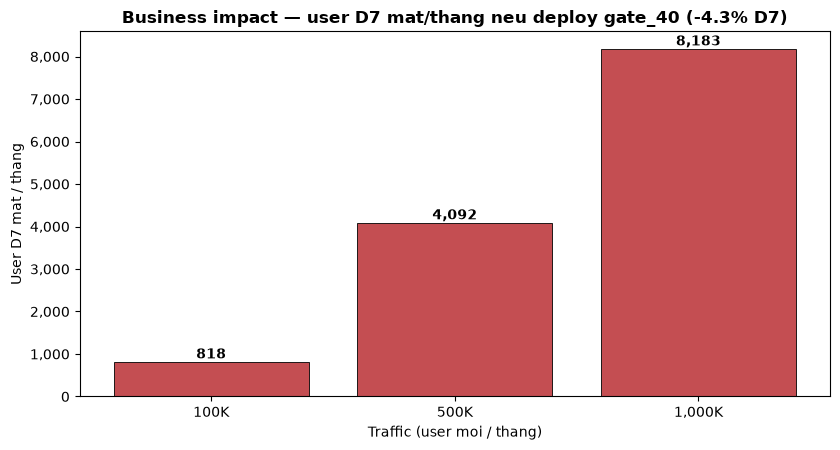

Saved: reports/phase4_g4_business_impact.png


In [13]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
lost_users = [t*abs(abs_impact) for t in TRAFFIC]
labels = [f'{t//1000:,}K' for t in TRAFFIC]
bars = ax.bar(labels, lost_users, color='#C44E52', edgecolor='black', linewidth=0.6)
for bar, v in zip(bars, lost_users):
    ax.text(bar.get_x()+bar.get_width()/2, v, f'{v:,.0f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('User D7 mat / thang')
ax.set_xlabel('Traffic (user moi / thang)')
ax.set_title(f'Business impact — user D7 mat/thang neu deploy gate_40 ({rel_impact:+.1f}% D7)',
             fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.grid(False)
fig.tight_layout()
fig.savefig('../reports/phase4_g4_business_impact.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: reports/phase4_g4_business_impact.png')